In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import tqdm

# Анализ детерминированной задачи

Определим вспомогательные функции.

In [2]:
from stochastique.core.numerical import find_jacobian, find_equilibrium, classify_equilibrium

Определим класс двумерной динамической системы с возможностью нахождения решения методом Рунге-Кутты 4 порядка с суммарной ошибкой $O(h^4)$ на интервале решения, с возможностью построения бифуркационной диаграммы и фазового портрета системы, нахождения равновесий и предельных циклов.

In [3]:
from stochastique.core.dynamic import DynamicSystem2D

# 1. Нейронная модель ФитцХью-Нагумо (FHN)

$$
\begin{cases}
    \dot{x} = \frac{1}{\delta} (x - \frac{x^3}{3} - y) \\
    \dot{y} = x + a
\end{cases}
$$

1. Найдем равновесия системы.

$$
\begin{cases}
    \frac{1}{\delta} (x - \frac{x^3}{3} - y) = 0 \\
    x + a = 0
\end{cases} \implies
\begin{cases}
    \overline{x} = -a \\
    \overline{y} = \frac{a^3}{3} - a
\end{cases}
$$

2. Исследуем равновесия на устойчивость.

$$
J(x, y) = \begin{pmatrix}
\frac{1}{\delta} (1 - x^2) & \frac{1}{\delta} \\
1 & 0
\end{pmatrix}
$$

$$
|J(x, y) - \lambda E| = 0
$$

$$
\lambda_{1,2}(x, y) = \frac{-\delta x^2 + \delta \pm \delta \sqrt{x^4 - 2 x^2 - 4 \delta + 1}}{2 \delta^2}
$$

Далее с помощью численной процедуры исследуем поведение собственных чисел якобиана в равновесных точках при различных значениях параметра $a$.

In [4]:
from stochastique.models.FHN import model_FHN, equilibria_FHN

In [5]:
FHN = DynamicSystem2D(
    model_FHN,
    params=dict(delta=0.1, a=1)
)

3. Построим бифуркационную диаграмму по параметру $a$.

Text(0.5, 1.0, 'FHN bifurcation diagram ($x_0$ = [0. 0.])')

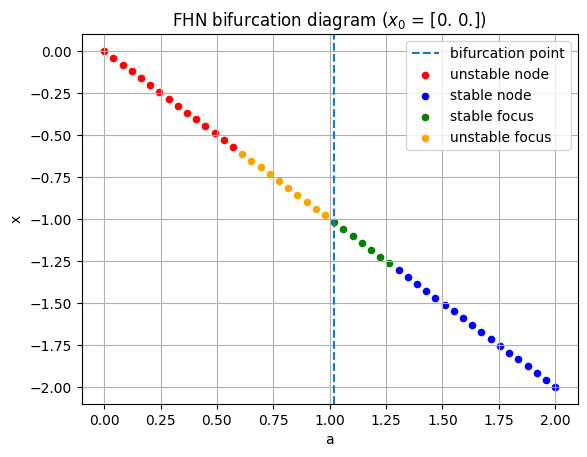

In [6]:
param_name = 'a'
param_values = np.linspace(0, 2, num=50)
state_init = lambda a: np.array([0., 0.])

fig, ax = plt.subplots()

bifurcation_points, equilibria = FHN.plot_bifurcation_diagram(
    param_name=param_name,
    param_values=param_values,
    state_init=state_init,
    ax=ax
)

a_bif = bifurcation_points[0]

ax.set_title(rf'FHN bifurcation diagram ($x_0$ = {np.round(state_init(0), 3)})')

4. Построим типичные фазовые портреты для различных значений $a$ по бифуркационной диаграмме.

In [8]:
from stochastique.util.plot import legend_unique_labels

Test trajectories and search cycles:   0%|          | 0/64 [00:00<?, ?it/s]/mnt/data/vnts/projects/urfu/2026-spring_stochastic-analysis/src/stochastique/models/FHN.py:20: RuntimeWarning: overflow encountered in scalar power
  (x - (x ** 3) / 3 - y) / delta,
/mnt/data/vnts/projects/urfu/2026-spring_stochastic-analysis/src/stochastique/models/FHN.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  (x - (x ** 3) / 3 - y) / delta,
Test trajectories and search cycles:  89%|████████▉ | 57/64 [00:42<00:05,  1.33it/s]/mnt/data/vnts/projects/urfu/2026-spring_stochastic-analysis/src/stochastique/models/FHN.py:20: RuntimeWarning: overflow encountered in scalar divide
  (x - (x ** 3) / 3 - y) / delta,
Test trajectories and search cycles: 100%|██████████| 64/64 [00:47<00:00,  1.34it/s]


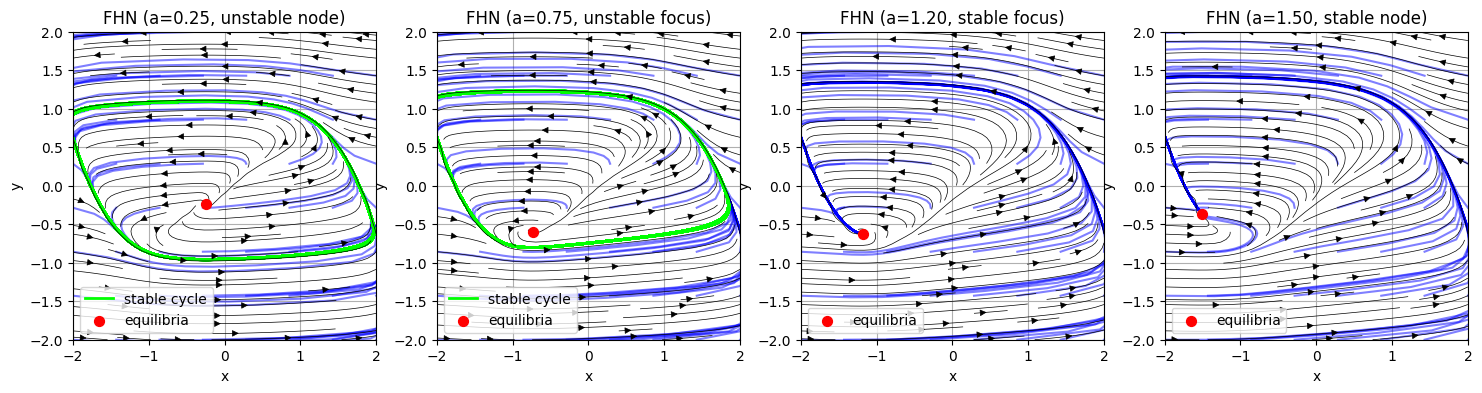

In [9]:
time_span = np.linspace(0, 50, num=10 ** 3)

a_min = param_values[0]
a_max = param_values[-1]
a_values_to_types = [
    (0.25, "unstable node"),
    (0.75, "unstable focus"),
    (1.2, "stable focus"),
    (1.5, "stable node")
]
a_values, equilibrium_types = zip(*a_values_to_types)

equilibria_per_value = np.concatenate((param_values[:, None], equilibria), axis=1)
tolerance = abs(param_values[1] - param_values[0]) / 2

fig, axes = plt.subplots(1, len(a_values_to_types), figsize=(18, 4))

for ax, a, eq_type in zip(axes, a_values, equilibrium_types):
    FHN.params['a'] = a
    FHN.plot_phase_portrait_dense(
        ax=ax,
        time_span=time_span,
        bounds=(-2, 2),
        grid_size=8,
    )

    equilibrium_idx = np.isclose(equilibria_per_value[:, 0], a, atol=tolerance)
    equilibrium_value = equilibria_per_value[equilibrium_idx][0]
    equilibrium_point = equilibrium_value[1:]

    ax.scatter(*equilibrium_point, color='red', marker='o', s=50, zorder=100, label='equilibria')
    ax.set_title(f"FHN ({a=:.2f}, {eq_type})")
    legend_unique_labels(ax, loc="lower left")

**Итог**. Нейронная модель ФитцХью-Нагумо имеет одну точку бифуркации $a = 1$. При анализе системы была рассмотрена и визуализирована ее единственная равновесная точка. При изменении параметра $a$, равновесная точка меняет тип 3 раза, а также после бифуркации в точке $a = 1$ предельный цикл исчезает.

# 2. Климатическая модель Зальцман-Николис (SN)

$$
\begin{cases}
    \dot{x} = y - x \\
    \dot{y} = -a x + b y - x^2 y
\end{cases}
$$

1. Найдем равновесия системы.

$$
\begin{cases}
    y - x = 0 \\
    -a x + b y - x^2 y = 0
\end{cases}

\implies

\begin{cases}
    x = y \\
    x(x^2 + a - b) = 0
\end{cases}

\implies

\begin{cases}
    (\overline{x}_1, \overline{y}_1) = (0, 0) \\
    (\overline{x}_2, \overline{y}_2) = (\sqrt{b - a}, \sqrt{b - a}) \\
    (\overline{x}_3, \overline{y}_3) = (-\sqrt{b - a}, -\sqrt{b - a})
\end{cases}
$$

2. Исследуем равновесия на устойчивость.

$$
J(x, y) = \begin{pmatrix}
-1 & 1 \\
-a - 2xy & b - x^2
\end{pmatrix}
$$

$$
|J(x, y) - \lambda E| = 0
$$

$$
\lambda_{1,2}(x, y) = \frac{\pm \sqrt{-4a + b^2 - 2b x^2 + 2b + x^4 - 2x^2 - 8xy + 1} + b - x^2 - 1}{2}
$$

Далее с помощью численной процедуры исследуем поведение собственных чисел якобиана в равновесных точках при различных значениях параметра $a$.

In [10]:
from stochastique.models.SN import model_SN, equilibria_SN

In [11]:
SN = DynamicSystem2D(
    model_SN,
    params=dict(a=1, b=2)
)

3. Построим бифуркационную диаграмму по параметру $a$ для трех равновесий системы:

$$
\begin{cases}
    (\overline{x}_1, \overline{y}_1) = (0, 0) \\
    (\overline{x}_2, \overline{y}_2) = (\sqrt{b - a}, \sqrt{b - a}) \\
    (\overline{x}_3, \overline{y}_3) = (-\sqrt{b - a}, -\sqrt{b - a})
\end{cases}
$$

Text(0.5, 1.0, 'SN bifurcation diagram ($x_0^{(1)}$ = [0. 0.], $x_0^{(2)}$ = [1.4 1.4], $x_0^{(3)}$ = [-1.4 -1.4])')

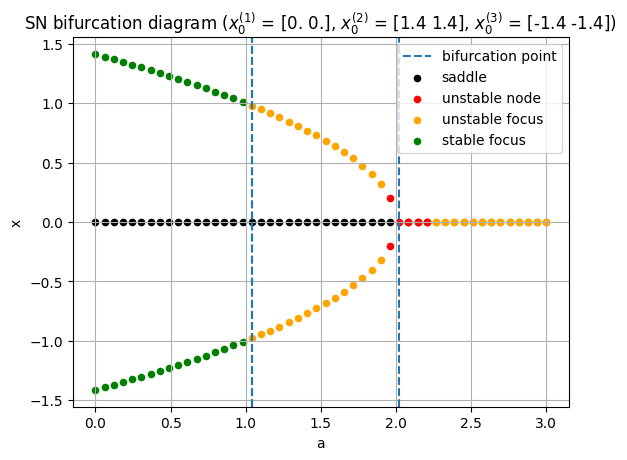

In [12]:
param_name = 'a'
param_values = np.linspace(0, 3, num=50)

b = 2
states_init = [
    lambda a: np.array([0., 0.]),
    lambda a: np.array([np.sqrt(b - a), np.sqrt(b - a)]),
    lambda a: -np.array([np.sqrt(b - a), np.sqrt(b - a)])
]
equilibria_per_state = []
bif_points_per_state = []

fig, ax = plt.subplots()

for state_init in states_init:
    bifurcation_points, equilibria = SN.plot_bifurcation_diagram(
        param_name=param_name,
        param_values=param_values,
        state_init=state_init,
        ax=ax
    )

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.set_title(
    r'SN bifurcation diagram ('
    '$x_0^{(1)}$ = '
    f'{np.round(states_init[0](0), 1)}, '
    '$x_0^{(2)}$ = '
    f'{np.round(states_init[1](0), 1)}, '
    '$x_0^{(3)}$ = '
    f'{np.round(states_init[2](0), 1)})'
)

#     a_bif = bifurcation_points[0]
#     equilibria_per_state.append(equilibria)
#     bif_points_per_state.append(a_bif)

# equilibria = equilibria_per_state[0]
# a_bif = bif_points_per_state[0]

4. Построим типичные фазовые портреты для различных значений $a$ по бифуркационной диаграмме равновесия $(\overline{x}_1, \overline{y}_1) = (0, 0)$.

In [14]:
from stochastique.util.plot import legend_unique_labels

Test trajectories and search cycles:   0%|          | 0/100 [00:00<?, ?it/s]/mnt/data/vnts/projects/urfu/2026-spring_stochastic-analysis/src/stochastique/models/SN.py:21: RuntimeWarning: overflow encountered in scalar multiply
  -a * x + b * y - (x ** 2) * y
/mnt/data/vnts/projects/urfu/2026-spring_stochastic-analysis/src/stochastique/models/SN.py:21: RuntimeWarning: invalid value encountered in scalar subtract
  -a * x + b * y - (x ** 2) * y
Stable limit cycle found!:   1%|          | 1/100 [00:00<00:39,  2.52it/s]  /mnt/data/vnts/projects/urfu/2026-spring_stochastic-analysis/src/stochastique/models/SN.py:21: RuntimeWarning: overflow encountered in scalar power
  -a * x + b * y - (x ** 2) * y
Stable limit cycle found!: 100%|██████████| 100/100 [00:40<00:00,  2.46it/s]


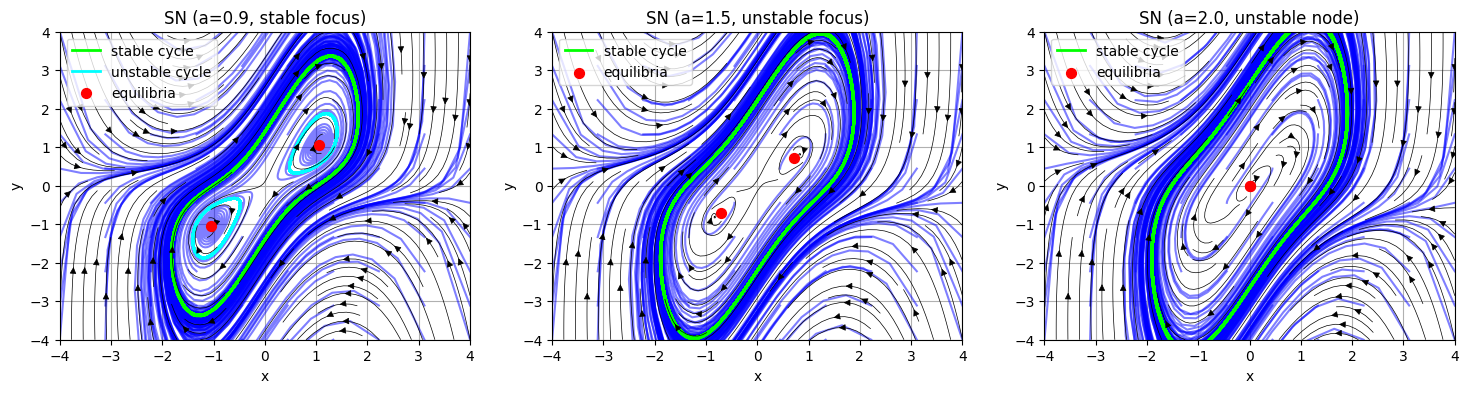

In [15]:
time_span = np.linspace(0, 100, num=10 ** 3)

a_values_to_types = [
    # (0.5, "stable focus"),
    (0.9, "stable focus"),
    (1.5, "unstable focus"),
    (2.0, "unstable node")
]
a_values, equilibrium_types = zip(*a_values_to_types)

n_plots = len(a_values_to_types)
fig, axes = plt.subplots(1, n_plots, figsize=(n_plots * 6, 4))

for ax, a, eq_type in zip(axes, a_values, equilibrium_types):
    SN.params['a'] = a
    SN.plot_phase_portrait_dense(
        ax=ax,
        time_span=time_span,
        bounds=(-4, 4),
        grid_size=10,
        seacrh_limit_cycles=True,
    )

    equilibrium_points_all = [
        # np.array([0, 0]),
        np.array([np.sqrt(b - a), np.sqrt(b - a)]),
        np.array([-np.sqrt(b - a), -np.sqrt(b - a)])
    ]
    
    for point in equilibrium_points_all:
        ax.scatter(*point, color='red', marker='o', s=50, zorder=100, label='equilibria')
    
    legend_unique_labels(ax, loc="upper left")
    ax.set_title(f"SN ({a=:.1f}, {eq_type})")

**Итог**. Климатическая модель Зальцман-Николис имеет одну точку бифуркации $a = 2$ для равновесия $(\overline{x}_1, \overline{y}_1) = (0, 0)$. При анализе системы была рассмотрена и визуализирована одна действительная равновесная точка из трех существующих. При изменении параметра $a$, равновесная точка меняет тип 2 раза, а также меняется количество и форма предельных цклов.